## Install dependencies

In [1]:
# DSAI 353 - Assignment 1: Language Model Benchmarking
!pip install -q transformers datasets accelerate evaluate matplotlib torch tqdm optimum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 433.6/433.6 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 14.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires f

## Import libraries

In [2]:
import os
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import (
    AutoTokenizer, 
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling,
    GPTNeoXForCausalLM
)
from tqdm.auto import tqdm

2025-04-25 21:58:20.212995: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745618300.401616      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745618300.458166      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Setup and reproducibility

In [3]:
# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Load base model

In [4]:
print("Step 1: Loading the base model...")
model_name = "distilgpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
base_model = AutoModelForCausalLM.from_pretrained(model_name)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model.to(device)
print(f"Model loaded: {model_name}")
print(f"Model parameters: {sum(p.numel() for p in base_model.parameters() if p.requires_grad):,}")

Step 1: Loading the base model...


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model loaded: distilgpt2
Model parameters: 81,912,576


## Load and preprocess datasets

In [5]:
# Step 2: Loading datasets
print("\nStep 2: Loading datasets...")
datasets = {
    "wikitext": load_dataset("wikitext", "wikitext-2-raw-v1", split="test"),
    "gsm8k": load_dataset("gsm8k", "main", split="test")
}

# Preprocess datasets
print("Preprocessing datasets...")
datasets["gsm8k"] = datasets["gsm8k"].map(lambda x: {"text": x["question"]})

# Sample to reduce computation
sample_size = 5000
sampled_datasets = {}
for name, dataset in datasets.items():
    if len(dataset) > sample_size:
        sampled_datasets[name] = dataset.select(range(sample_size))
    else:
        sampled_datasets[name] = dataset
    print(f"{name}: {len(sampled_datasets[name])} samples")


Step 2: Loading datasets...


README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/733k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/6.36M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/657k [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

Preprocessing datasets...


Map:   0%|          | 0/1319 [00:00<?, ? examples/s]

wikitext: 4358 samples
gsm8k: 1319 samples


## Define benchmarking functions

In [6]:
# Function to measure throughput
def benchmark_model(model, tokenizer, dataset, batch_size=8, max_length=128):
    model.eval()
    total_tokens = 0
    total_time = 0
    for i in range(0, len(dataset), batch_size):
        batch_texts = dataset[i:i+batch_size]["text"]
        inputs = tokenizer(
            batch_texts, 
            return_tensors="pt", 
            padding=True, 
            truncation=True, 
            max_length=max_length
        ).to(device)
        tokens_in_batch = inputs['input_ids'].numel()
        total_tokens += tokens_in_batch
        with torch.no_grad():
            start_time = time.time()
            _ = model(**inputs)
            end_time = time.time()
        total_time += (end_time - start_time)
    throughput = total_tokens / total_time if total_time > 0 else 0
    return throughput

# Function to run benchmarks
def run_benchmarks(model, tokenizer, datasets):
    results = {}
    print("\nRunning benchmarks...")
    for name, dataset in datasets.items():
        print(f"Benchmarking on {name}...")
        throughput = benchmark_model(model, tokenizer, dataset)
        results[name] = throughput
        print(f"{name} throughput: {throughput:.2f} tokens/sec")
    return results

## Run benchmarks on base model

In [7]:
# Benchmark the base model
base_results = run_benchmarks(base_model, tokenizer, sampled_datasets)


Running benchmarks...
Benchmarking on wikitext...
wikitext throughput: 148122.30 tokens/sec
Benchmarking on gsm8k...
gsm8k throughput: 129819.66 tokens/sec


## Optimize model

In [8]:
# Step 4: Optimizing the model
print("\nStep 4: Optimizing the model...")
optimized_model = AutoModelForCausalLM.from_pretrained(model_name)
optimized_model = optimized_model.half()
optimized_model.to(device)

if hasattr(optimized_model.config, "use_flash_attention") and torch.cuda.is_available():
    optimized_model.config.use_flash_attention = True
    print("Flash Attention enabled")

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True


Step 4: Optimizing the model...


## Benchmark optimized model

In [9]:
# Benchmark the optimized model
optimized_results = run_benchmarks(optimized_model, tokenizer, sampled_datasets)


Running benchmarks...
Benchmarking on wikitext...
wikitext throughput: 166469.29 tokens/sec
Benchmarking on gsm8k...
gsm8k throughput: 136712.23 tokens/sec


## Fine-tuning preparation

In [10]:
# Step 7: Fine-tuning the model
print("\nStep 7: Fine-tuning the model...")
train_dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="train[:1%]")

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

tokenized_dataset = train_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)



Step 7: Fine-tuning the model...


Map:   0%|          | 0/367 [00:00<?, ? examples/s]

## Set up Trainer

In [11]:
# Training arguments
training_args = TrainingArguments(
    output_dir="./results",
    overwrite_output_dir=True,
    num_train_epochs=1,
    per_device_train_batch_size=8,
    save_steps=10_000,
    save_total_limit=2,
    fp16=True,
    logging_steps=50,
    report_to="none"
)

finetuned_model = AutoModelForCausalLM.from_pretrained(model_name)
finetuned_model.to(device)

trainer = Trainer(
    model=finetuned_model,
    args=training_args,
    train_dataset=tokenized_dataset,
    data_collator=data_collator,
    tokenizer=tokenizer,
)

/tmp/ipykernel_19/2501695600.py:17: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


## Fine-tune model

In [12]:
# Start fine-tuning
trainer.train()

`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.


Step,Training Loss


TrainOutput(global_step=23, training_loss=2.2870101928710938, metrics={'train_runtime': 7.1478, 'train_samples_per_second': 51.345, 'train_steps_per_second': 3.218, 'total_flos': 11986988433408.0, 'train_loss': 2.2870101928710938, 'epoch': 1.0})

## Benchmark fine-tuned model

In [13]:
# Benchmark fine-tuned model
finetuned_results = run_benchmarks(finetuned_model, tokenizer, sampled_datasets)


Running benchmarks...
Benchmarking on wikitext...
wikitext throughput: 169494.62 tokens/sec
Benchmarking on gsm8k...
gsm8k throughput: 136556.58 tokens/sec


## Plot individual dataset results


Step 9: Plotting the results...


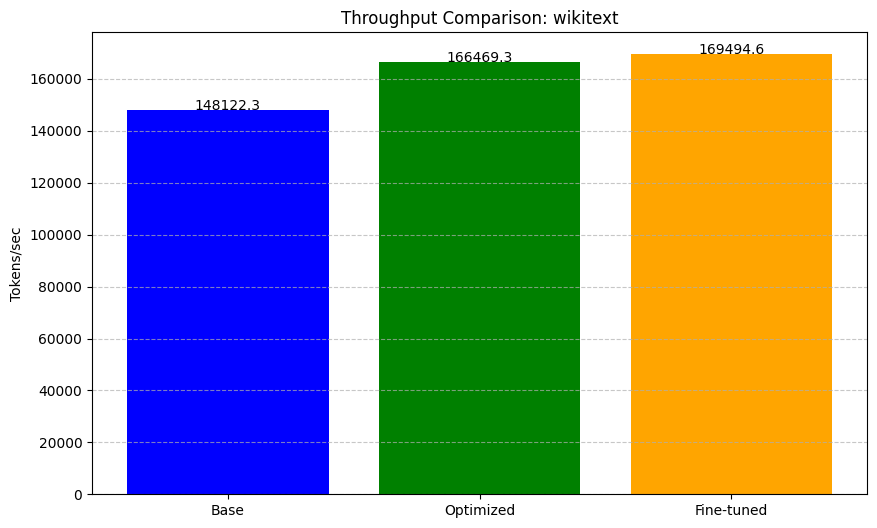

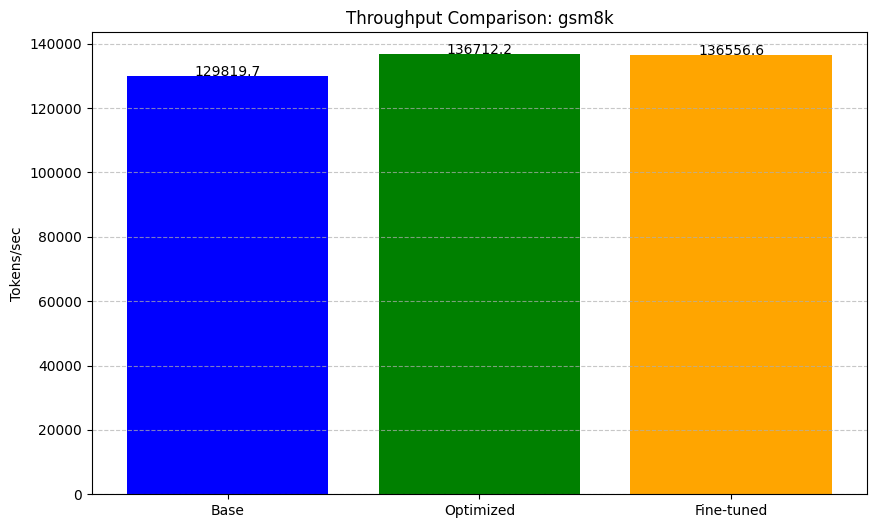

In [14]:
# Step 9: Plotting the results
print("\nStep 9: Plotting the results...")
all_results = {
    dataset_name: {
        "Base": base_results[dataset_name],
        "Optimized": optimized_results[dataset_name],
        "Fine-tuned": finetuned_results[dataset_name]
    }
    for dataset_name in base_results.keys()
}

for dataset_name, results in all_results.items():
    plt.figure(figsize=(10, 6))
    versions = list(results.keys())
    values = list(results.values())
    plt.bar(versions, values, color=["blue", "green", "orange"])
    plt.title(f"Throughput Comparison: {dataset_name}")
    plt.ylabel("Tokens/sec")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    for i, v in enumerate(values):
        plt.text(i, v + 50, f"{v:.1f}", ha='center')
    plt.savefig(f"{dataset_name}_throughput.png")
    plt.show()

## Plot combined throughput

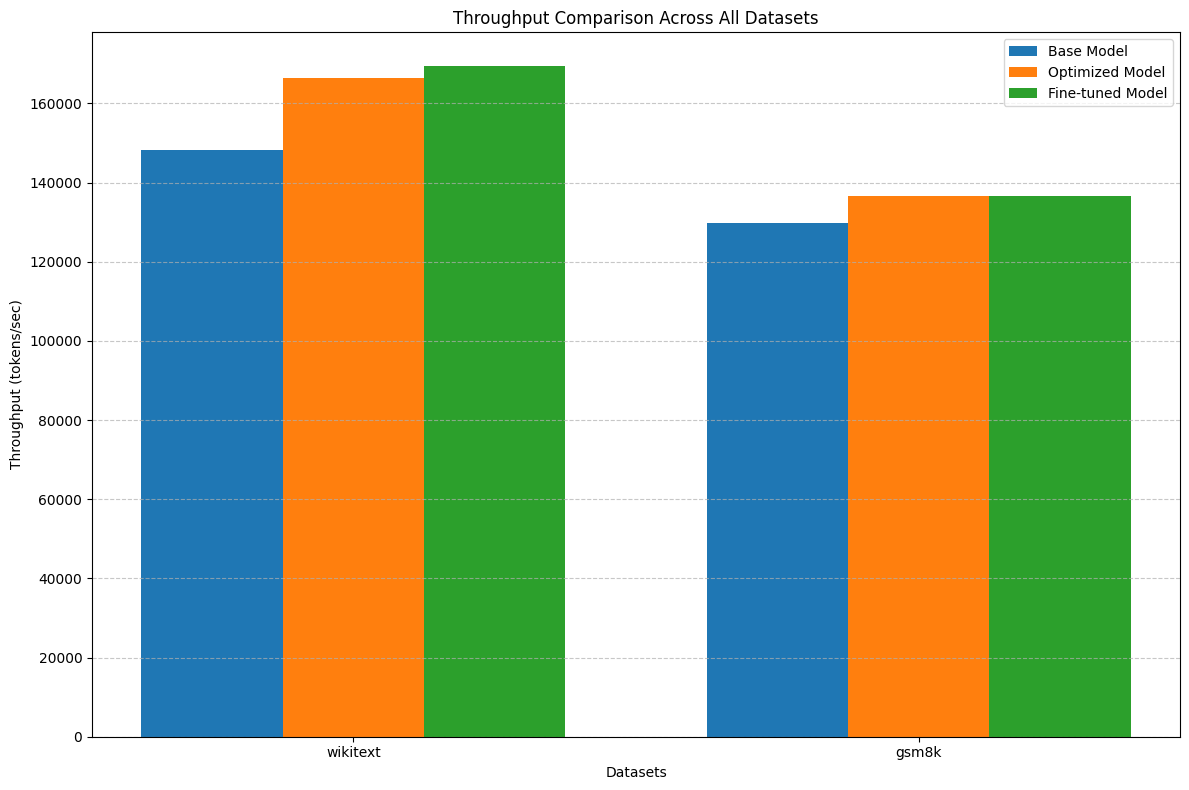

In [15]:
# Combined plot
plt.figure(figsize=(12, 8))
x = np.arange(len(base_results))
width = 0.25

plt.bar(x - width, [base_results[d] for d in base_results], width, label='Base Model')
plt.bar(x, [optimized_results[d] for d in optimized_results], width, label='Optimized Model')
plt.bar(x + width, [finetuned_results[d] for d in finetuned_results], width, label='Fine-tuned Model')

plt.xlabel('Datasets')
plt.ylabel('Throughput (tokens/sec)')
plt.title('Throughput Comparison Across All Datasets')
plt.xticks(x, list(base_results.keys()))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("overall_throughput_comparison.png")
plt.show()

## Print throughput improvement stats

In [16]:
# Print throughput improvement
print("\nFinal Throughput Improvement Statistics:")
print("-" * 60)
print(f"{'Dataset':<10} | {'Base':<10} | {'Optimized':<10} | {'Fine-tuned':<10} | {'Opt Gain %':<10} | {'FT Gain %':<10}")
print("-" * 60)

for dataset in base_results:
    base = base_results[dataset]
    opt = optimized_results[dataset]
    ft = finetuned_results[dataset]
    
    opt_gain = ((opt - base) / base * 100) if base > 0 else float('inf')
    ft_gain = ((ft - base) / base * 100) if base > 0 else float('inf')
    
    print(f"{dataset:<10} | {base:<10.2f} | {opt:<10.2f} | {ft:<10.2f} | {opt_gain:<10.2f} | {ft_gain:<10.2f}")

print("-" * 60)
print("\nBenchmarking complete!")


Final Throughput Improvement Statistics:
------------------------------------------------------------
Dataset    | Base       | Optimized  | Fine-tuned | Opt Gain % | FT Gain % 
------------------------------------------------------------
wikitext   | 148122.30  | 166469.29  | 169494.62  | 12.39      | 14.43     
gsm8k      | 129819.66  | 136712.23  | 136556.58  | 5.31       | 5.19      
------------------------------------------------------------

Benchmarking complete!
